In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/dataset1 june 3"

In [3]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [5]:
num_classes = len(train_ds.class_names)
print(train_ds.class_names)

['PESTAL~1', 'cordana', 'healthy', 'sigatoka']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [7]:
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
base_model.trainable = False

In [9]:
model = Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')

])

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,090,372 (91.90 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 229s 5s/step - accuracy: 0.8031 - loss: 0.5332 - val_accuracy: 0.9656 - val_loss: 0.1394
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9570 - loss: 0.1268 - val_accuracy: 0.9781 - val_loss: 0.0929
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9820 - loss: 0.0625 - val_accuracy: 0.9625 - val_loss: 0.1042
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step - accuracy: 0.9930 - loss: 0.0315 - val_accuracy: 0.9719 - val_loss: 0.1018
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9961 - loss: 0.0217 - val_accuracy: 0.9750 - val_loss: 0.0934
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.9961 - loss: 0.0160 - val_accuracy: 0.9750 - val_loss: 0.0904
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.9984 - loss: 0.0110 - val_accuracy: 0.9781 - val_loss: 0.0885
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.9992 - loss: 0.0074 - val_accuracy: 0.9

In [13]:
model.save("resnet50v2_model.h5")

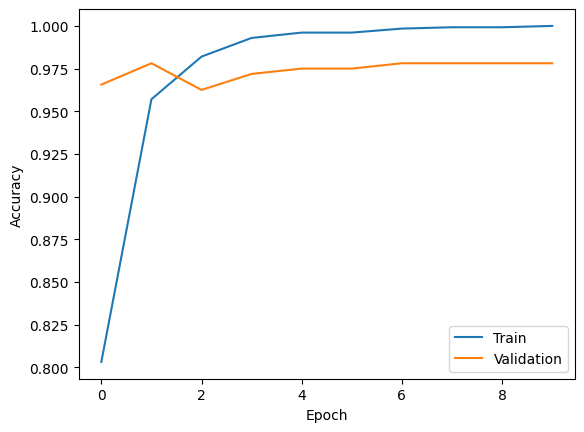

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix

In [16]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [17]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[67  1  1  1]
 [ 2 90  0  0]
 [ 0  0 78  0]
 [ 0  2  0 78]]


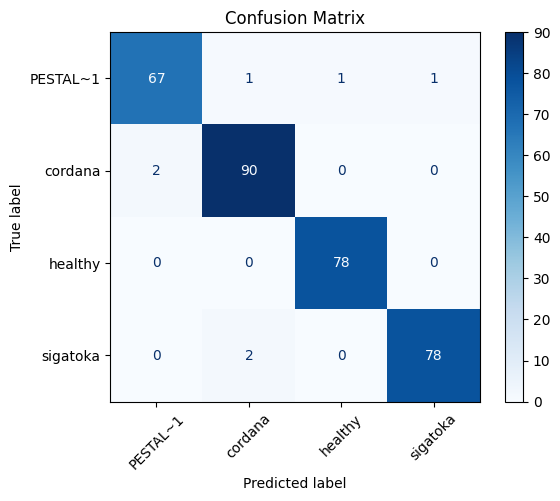

In [23]:
class_names = ['PESTAL~1', 'cordana', 'healthy', 'sigatoka']

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    PESTAL~1       0.97      0.96      0.96        70
     cordana       0.97      0.98      0.97        92
     healthy       0.99      1.00      0.99        78
    sigatoka       0.99      0.97      0.98        80

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320

